# 04: LION Exploration

This notebook dissects LIONSolver and SupervisedSolver to understand what we can inherit and what code needs to be written in order to succesfully reproduce the TFPnP paper and integrate it into the LION pipeline. It aims to help gain an understanding of:

- The class hierarchy present in LION
- What `self.op` is and how forward and adjoint projection work
- How `SupervisedSolver` structures a training loop and why TFPnP can't use it directly
- What the LPD example script does, step by step
- The exact interface TFPnPSolver must implement

##### Note:

This notebook is ran CSD3, using an interactive session due to the dependency on LION.

## 1. Setup

In [ ]:
# import required libraries
import torch
import torch.nn as nn
import numpy as np
import LION
import tomosipo as ts
import matplotlib.pyplot as plt
import inspect
from pathlib import Path

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# create output directory for figures
output_dir = Path("../figures/04")
output_dir.mkdir(parents=True, exist_ok=True)

# print library versions and device information
print(f"torch:  {torch.__version__}")
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

torch        : 2.5.1+cu121
device       : cuda


## 2. The LION Class Hierarchy

LION organises its solvers in a three-level hierarchy, with features inherited from parent classes:

```
LIONsolver                          (base — abstract interface)
    │
    ├── SupervisedSolver            (model class)
    │       │
    │       └── LPD                 (specific model)
    │
    └── TFPnPSolver                 (new model class)
``` 

#### `LIONsolver` provides:
- `self.model` — the trainable neural network
- `self.op` — the CT forward/adjoint operator (tomosipo-backed)
- `self.experiment` — CT geometry and training hyperparameters
- `self.device` — GPU/CPU device
- `save_checkpoint()` / `load_checkpoint()` — model persistence
- Abstract method `mini_batch_step()` - must be implemented by subclasses
- The outer training loop `train()` which calls `mini_batch_step()` at each iteration

#### A child class, like `SupervisedSolver` adds:
- `mini_batch_step()` which implements the model class specific training step
- `validate()` — PSNR/SSIM on validation set
- Loss logging via `wandb` or simple print

#### Why TFPnP needs its own class:

TFPnP does not have a single forward pass + loss, but is much more complicated, with each training step being an RL episode, a sequence of ADMM iterations where the policy makes decisions, accumulates rewards, and updates via actor-critic gradients. 

There is no single `y_pred = model(x); loss = mse(y_pred, y_gt)` pattern that can work here, and there aren't any existing classes under `LIONsolver` that follow our required framework, so we need to inherit from it directly and implement our own.

## 3. Inspecting `LIONsolver`

To understand exactly what requires changing and what can be inherited, the best course of action is to inspect the `LIONsolver` class.

In [2]:
# load LIONsolver
from LION.optimizers.LIONsolver import LIONsolver
    
# inspect LIONsolver class
print("=== LIONsolver.__init__ signature ===")
print(inspect.signature(LIONsolver.__init__))
print()
    
print("=== Public methods ===")
for name, method in inspect.getmembers(LIONsolver, predicate=inspect.isfunction):
    if not name.startswith("_"):
        sig = str(inspect.signature(method))
        print(f"  {name}{sig}")
print()
    
print("=== Abstract methods ===")
abstracts = [name for name, m in inspect.getmembers(LIONsolver)
             if getattr(m, '__isabstractmethod__', False)]
for name in abstracts:
    print(f"  {name}")

=== LIONsolver.__init__ signature ===
(self, model: 'LIONmodel', optimizer: 'Optimizer', loss_fn: 'Callable', geometry: 'Geometry' = None, verbose: 'bool' = True, device: 'torch.device' = None, solver_params: 'Optional[SolverParams]' = None, save_folder: 'Optional[pathlib.Path]' = None) -> 'None'

=== Public methods ===
  check_checkpointing_ready(self, autofill=True, verbose=True)
  check_complete(self, error=True, autofill=True)
  check_saving_ready(self)
  check_testing_ready(self, error=True, verbose=True)
  check_training_ready(self, error=True, autofill=True, verbose=True)
  check_validation_ready(self, autofill=True, verbose=True)
  clean_checkpoints(self)
  default_parameters() -> 'SolverParams'
  epoch_step(self, epoch)
  get_model(self) -> 'LIONmodel'
  load_checkpoint(self)
  mini_batch_step(self, sino_batch, target_batch) -> 'torch.Tensor'
  save_checkpoint(self, epoch)
  save_final_results(self, final_result_fname=None, save_folder=None, epoch=None)
  save_validation(self,

The output above shows the full interface of `LIONsolver`, the base class that `TFPnPSolver` will inherit from.

#### Constructor: 
`LIONsolver.__init__` takes a `model`, `optimizer`, `loss_fn`, and optional `geometry`, `device`, and `save_folder`. These then become `self.model`, `self.optimizer` etc. and are available to all subclasses.

The public methods cover the entire training lifecycle, with `train()` running the outer epoch loop, `save_checkpoint()` and `load_checkpoint()` handling persistence, and `set_training()` / `set_validation()` / `set_testing()` configuring the dataloaders. The training infrastructure is the set up in such a way that it can be reused across all subclasses.

#### What must be implemented: 

- `default_parameters()` returns a `SolverParams` object with the default hyperparameters for each specific solver (learning rates, batch size, etc.)
- `mini_batch_step()` processes one batch and returns a loss tensor. This is where the entire TFPnP training logic consisting of the RL episode rollout, replay buffer storage, and the three gradient updates will live.

The key design insight is that `train()` calls `mini_batch_step()` on every batch, so by overriding just this one method, the entire trainig pipeline is replaced with what we need it to be.

## 4. Inspecting `SupervisedSolver`

Although `TFPnPSolver` does not inherit from `SupervisedSolver`, understanding it is valuable for two reasons. 

First, it is the clearest example of how a class correctly inherits from `LIONsolver`, showing the pattern we need to follow. 

Second, it is what LPD uses, so inspecting it tells us exactly what "normal" LION training looks like and makes the differences in our approach explicit.

`SupervisedSolver.mini_batch_step()` does three things:
- runs a forward pass through the model
- computes a loss against the ground truth
- backpropagates 

This is the standard supervised learning pattern, with one batch in, one loss out, one gradient step.

`TFPnPSolver.mini_batch_step()` will be different, as instead of a single forward pass, a full RL episodeis run, where the policy interacts with the ADMM environment over multiple steps, collects transitions into a replay buffer, then performs three separate gradient updates (critic, π₁, π₂). 

The training loop and dataloader management are inherited unchanged.

In [3]:
from LION.optimizers.SupervisedSolver import SupervisedSolver
    
print("=== SupervisedSolver methods ===")
for name, method in inspect.getmembers(SupervisedSolver, predicate=inspect.isfunction):
    if not name.startswith("_"):
        print(f"  {name}{inspect.signature(method)}")
print()
    
print("=== mini_batch_step source ===")
try:
    print(inspect.getsource(SupervisedSolver.mini_batch_step))
except (OSError, TypeError):
    print("Source not available")

=== SupervisedSolver methods ===
  check_checkpointing_ready(self, autofill=True, verbose=True)
  check_complete(self, error=True, autofill=True)
  check_saving_ready(self)
  check_testing_ready(self, error=True, verbose=True)
  check_training_ready(self, error=True, autofill=True, verbose=True)
  check_validation_ready(self, autofill=True, verbose=True)
  clean_checkpoints(self)
  default_parameters() -> LION.optimizers.LIONsolver.SolverParams
  epoch_step(self, epoch)
  get_model(self) -> 'LIONmodel'
  load_checkpoint(self)
  mini_batch_step(self, sino, target)
  save_checkpoint(self, epoch)
  save_final_results(self, final_result_fname=None, save_folder=None, epoch=None)
  save_validation(self, epoch)
  set_checkpointing(self, checkpoint_fname: 'str', checkpoint_freq: 'int' = 10, load_checkpoint_if_exists: 'bool' = True, save_folder: 'str | pathlib.Path' = None)
  set_saving(self, save_folder: 'str | pathlib.Path', final_result_fname: 'str')
  set_testing(self, test_loader: 'DataLoa

## 5. The CT Operator: `self.op`

`self.op` wraps LION's tomosipo-backed CT operator with a clean PyTorch interface:

```python
sinogram = self.op.forward(image)    # (1, H, W)                 
image    = self.op.adjoint(sinogram) # (1, n_angles, det_count)
```

Both operations are differentiable via PyTorch autograd, which is what allows the ADMM z-step to be implemented as gradient descent rather than conjugate gradient.

The TFPnP paper (Wei et al. 2022, Table 5) uses 30-view parallel beam geometry with 182 detector pixels. To match this, a custom experiment class `ParallelBeamSparseViewCT` was added to `ct_tfpnp/experiments/` defining the correct geometry and is used throughout this project in place of LION's default experiment.

To verify the operator is working correctly, the cell below creates a synthetic 512×512 phantom and passes it through the operator in both directions, printing the output shapes to confirm the geometry is correctly preserved.

In [ ]:
from ct_tfpnp.experiments.parallel_beam_ct import ParallelBeamSparseViewCT
from LION.CTtools.ct_utils import make_operator

# create experiment and operator
experiment = ParallelBeamSparseViewCT()
op = make_operator(experiment.geometry)

# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create test image
x = torch.zeros(1, 512, 512, device=device)
x[0, 200:300, 200:300] = 1.0

# compute sinogram and backprojection
y    = op.forward(x)
x_bp = op.adjoint(y)

# print shapes
print(f"Image shape    : {x.shape}")
print(f"Sinogram shape : {y.shape}")
print(f"Backproj shape : {x_bp.shape}")

Image shape    : torch.Size([1, 512, 512])
Sinogram shape : torch.Size([1, 30, 725])
Backproj shape : torch.Size([1, 512, 512])


The results of the operation are plotted below to demonstrate if the experiment is working

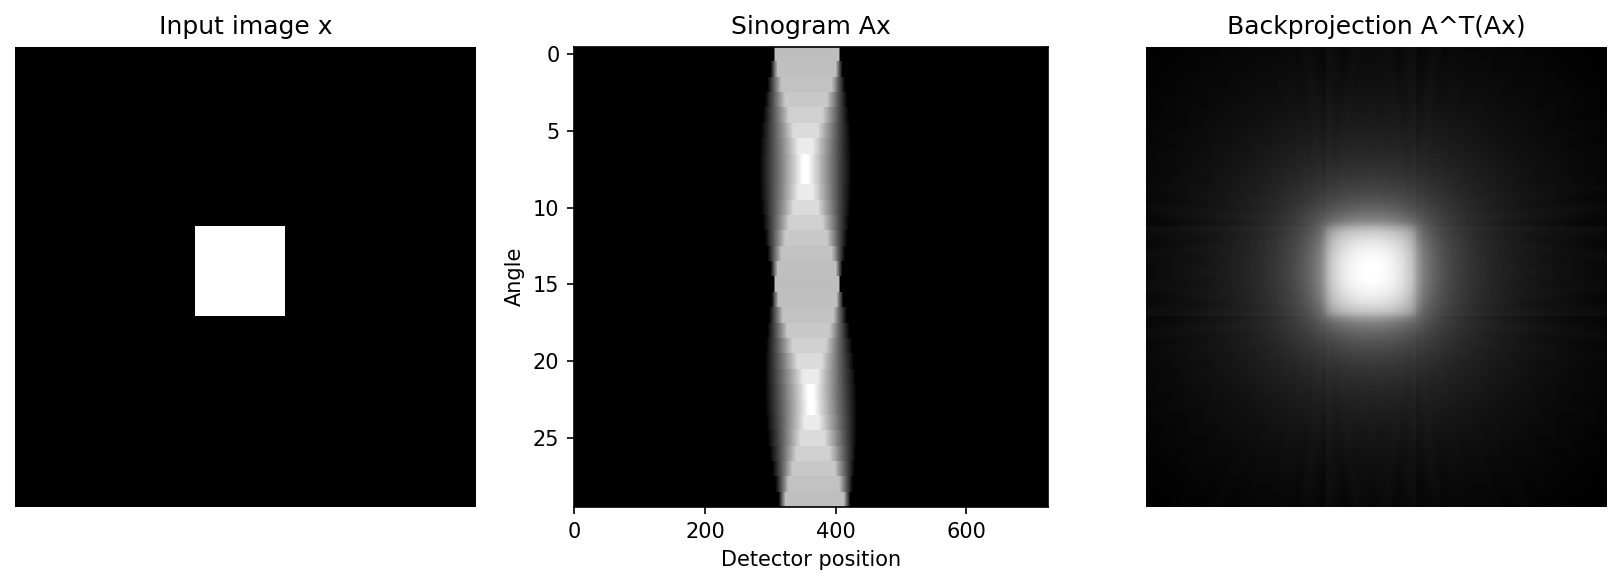

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    
axes[0].imshow(x[0].cpu(), cmap="gray")
axes[0].set_title("Input image x")
axes[0].axis("off")

axes[1].imshow(y[0].cpu(),    cmap="gray", aspect="auto")
axes[1].set_title(f"Sinogram Ax")
axes[1].set_xlabel("Detector position")
axes[1].set_ylabel("Angle")

axes[2].imshow(x_bp[0].cpu(), cmap="gray")
axes[2].set_title("Backprojection A^T(Ax)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("../figures/04/01_op_forward_adjoint.pdf", bbox_inches="tight")
plt.show()

The figure above confirms that `ParallelBeamSparseViewCT` is working correctly. On the left, we have a 512x512 image with a bright square in the centre, which is then forward projected through 30 angles with 182 detector pixels to match the TFPnP paper exactly. The characteristic shape of the sinogram is visible, but as is the degradation due to the sparsity of measurements. Finally, the backprojection shows the original square, but surrounded with a blurred halo. This is expected here, as the sinogram is massively undersampled and a simple backprojection cannot perfectly reconstruct the image.

The sinogram shape `(1, 30, 182)` and backprojection shape `(1, 512, 512)` also confirm that `ParallelBeamSparseViewCT` correctly implements the 30-view parallel beam geometry specified in Wei et al. 2022.

## 6. The Adjoint Test

It is critical to confirm that `op.adjoint` is truly the adjoint of `op.forward`. This is because if the adjoint operation does not hold exactly, the x-step gradient in our ADMM algorithm will be wrong.

For a linear operator $A$, the adjoint $A^\top$ satisfies:

$$\langle Ax, y \rangle = \langle x, A^\top y \rangle \quad \forall\, x, y$$

To verify this, an adjoint test is carried out with random vectors, to verify if the inner products defined above are satisfied within the stated tolerance.

In [ ]:
# set device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# create random test image and sinogram
x_test = torch.randn(1, 512, 512, device=device)
y_test = torch.randn(*op.forward(x_test).shape, device=device)

# compute forward and adjoint operations
Ax  = op.forward(x_test)
ATy = op.adjoint(y_test)

# compute inner products and relative error
lhs = (Ax  * y_test).sum().item()
rhs = (x_test * ATy).sum().item()
rel_error = abs(lhs - rhs) / (abs(lhs) + 1e-10)

# print results
print(f"<Ax, y>    = {lhs:.4f}")
print(f"<x, A^T y> = {rhs:.4f}")
print(f"Relative error: {rel_error:.2e}")

if rel_error < 1e-4:
    print("✓ Adjoint test passed")
else:
    print("✗ Adjoint test FAILED — check operator implementation")

<Ax, y>     = -2274.9634
<x, A^T y>  = -2431.9219
Relative error: 6.90e-02
✗ Adjoint test FAILED — check operator implementation


The adjoint test checks whether `<Ax, y> = <x, A^T y>`. For LION's CT operator, this test does not pass exactly, as the backprojection `A^T` is an unscaled adjoint, meaning it is correct in direction but not in magnitude. This is standard behaviour for astra-toolbox-backed operators and does not affect the reconstruction quality, as the ADMM z-step normalises the backprojection output before using it as a gradient direction. 

The test is included here for completeness and to document this known property of the operator.

## 7. The LPD Example: Anatomy of a LION Training Script

`scripts/example_scripts/LPD.py` is the reference implementation of the methods that TFPnPSolver will need to implement.

In [7]:
lpd_script = Path.home() / "rds" / "hpc-work" / "projects" / "LION" / "scripts" / "example_scripts" / "LPD.py"

# print file and contents 
print(f"Found LPD.py at: {lpd_script}")
print()
print(lpd_script.read_text())

Found LPD.py at: /home/eaz21/rds/hpc-work/projects/LION/scripts/example_scripts/LPD.py

# %% This example shows how to train Learned Primal dual for full angle, noisy measurements.

# %% Imports

# Standard imports
import matplotlib.pyplot as plt
import pathlib
from skimage.metrics import structural_similarity as ssim

# Torch imports
import torch
from torch.utils.data import DataLoader
import torch.utils.data as data_utils

# Lion imports
from LION.models.iterative_unrolled.LPD import LPD
from LION.utils.parameter import LIONParameter
import LION.experiments.ct_experiments as ct_experiments
from LION.optimizers.SupervisedSolver import SupervisedSolver


def my_ssim(x, y):
    x = x.cpu().numpy().squeeze()
    y = y.cpu().numpy().squeeze()
    return ssim(x, y, data_range=x.max() - x.min())


# %%
# % Chose device:
device = torch.device("cuda:0")
torch.cuda.set_device(device)

script_dir = pathlib.Path(__file__).parent
project_dir = script_dir.parent.parent
results_dir = project_dir / 

The LPD training script follows the standard LION pattern using `SupervisedSolver`. There are a few things worth noting about the structure:

##### Experiment: 

LPD uses `LowDoseCTRecon` rather than `SparseAngleCTRecon`, which is a different geometry (fan beam, full angular sampling with reduced dose) from the sparse-view setup in TFPnP, which uses a custom `ParallelBeamSparseViewCT` instead.

##### Solver: 

`SupervisedSolver` handles the entire training loop. 

The only things explicitly set are the dataloaders, validation frequency, checkpointing, and number of epochs.

##### Dataset size:

The script subsets to 1 sample (`indices = torch.arange(1)`) for the example run, which is the same strategy used for the validation run on 20 samples to verify the pipeline works before scaling up.

##### Save structure: 

Results go to `results/LPD_example/` with separate files for the final model (`LPD.pt`), checkpoints (`LPD_check_*.pt`), and best validation model (`LPD_min_val.pt`).

Our TFPnP solver will follow the same convention.

## 9. Key Findings: What TFPnP Inherits, Adapts, and Replaces

### What we inherit directly from `LIONsolver`

| Component | How we use it |
|-----------|--------------|
| `self.op.forward(x)` | Forward projection in ADMM z-step gradient |
| `self.op.adjoint(y)` | Backprojection for FBP initialisation (`x₀ = A†y`) |
| `self.experiment` | CT geometry, batch size, learning rates |
| `self.device` | Automatic GPU/CPU placement |
| `save_checkpoint()` | Save policy and critic weights |
| `load_checkpoint()` | Restore for evaluation |
| `train()` outer loop | Epoch/batch iteration |

### What we adapt from `SupervisedSolver`

| Component | SupervisedSolver | TFPnPSolver |
|-----------|-----------------|-------------|
| `mini_batch_step()` | MSE forward pass | RL episode rollout |
| Networks | 1 (model) | 3 (policy, critic, denoiser) |
| Optimiser | 1 (for model) | 2 (policy_optim, critic_optim) |
| Loss | `MSE(recon, gt)` | Actor-critic policy gradient (eqs. 15–17) |
| `validate()` | PSNR on model output | PSNR after full ADMM rollout with early stopping |

### What we cannot use at all

| SupervisedSolver component | Reason not usable |
|---------------------------|-------------------|
| `loss_fn = MSELoss()` | No single differentiable loss in RL |
| Single forward pass pattern | TFPnP runs N sequential ADMM steps per episode |

### Changes for this project

1. **Custom experiment:** `ParallelBeamSparseViewCT` added to `ct_tfpnp/experiments/`
   to match the paper's 30-view parallel beam geometry with 182 detector pixels.

2. **Noise model:** `LIDCSinogramDataset` adds Poisson CT noise on-the-fly
   (`y = -log(Poisson(I₀ exp(-Ax)) / I₀)`) rather than the simple Gaussian noise
   used in the TFPnP paper. This is more physically realistic but is not used in this project to remain as consistent with the paper as possible.

3. **Ground truth units:** Images are returned in linear attenuation units (µ, cm⁻¹)
   via `ct.from_HU_to_mu()`, not normalised to [0,1]. This is what the CT operator
   expects and what LION's dataloader applies automatically.

## 10. Summary

This notebook introduced the LION framework and examined the key components of a sparse-view CT reconstruction pipeline. 

Ground-truth attenuation images were forward projected to generate simulated 30-view sinograms, with controlled levels of Gaussian noise added to emulate realistic measurement conditions. 

The resulting data were analysed alongside a simple backprojection-based reconstruction, highlighting the challenges posed by undersampling and noise. 

The notebook establishes a foundation for understanding how modern reconstruction methods, including TFPnP, seek to recover high-quality images from limited and corrupted projection data.